# 02 - Factor research

Three price-volume factors, each in three representations:

| Factor | Raw factor (through close t) | Direction | Final signal |
|---|---|---:|---|
| Mean reversion | past *w*-day return | -1 | -z(winsorized raw) |
| Momentum | return from t-*w* to t-5 (skips last 5 days) | +1 | z(winsorized raw) |
| Volatility | annualized std of daily returns over *w* days | -1 | -z(winsorized raw) |

Lookbacks were chosen by validation-period Rank IC against the execution-aligned 5-day forward
return (purged at period ends). If the beta-neutral design variant is selected, the final signal is
additionally residualized on trailing 252-day stock betas and re-standardized.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
from IPython.display import Image, display
T, F, D = ROOT / "results/tables", ROOT / "results/figures", ROOT / "data/processed"
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.width", 200)
from src.config import figure_relpath, table_relpath
def table(name, **kw):
    return pd.read_csv(T / table_relpath(name), **kw)
def fig(key, width=1100):
    display(Image(filename=str(F / figure_relpath(key)), width=width))

## Lookback selection (validation only)

In [2]:
table("lookback_selection")

,factor,window,train_mean_ic,validation_mean_ic,validation_ic_ir,chosen
0,reversal,1,0.0115,-0.0007,-0.0040,False
1,reversal,5,0.0135,0.0152,0.0849,True
2,momentum,20,-0.0022,-0.0227,-0.1256,False
3,momentum,60,0.0022,-0.0078,-0.0415,False
4,momentum,120,0.0055,0.0057,0.0257,True
5,volatility,20,0.0063,-0.0069,-0.0318,False
6,volatility,60,0.0068,-0.0031,-0.0129,True


## Raw vs standardized vs final signal on one date

In [3]:
from src.config import load_config
from src.data import build_panel
from src.factors import build_factor
from src.preprocessing import build_universe, daily_returns
cfg = load_config()
panel = build_panel(cfg)
adj = panel["wide"]["adj_close"]; rets = daily_returns(adj)
universe = build_universe(panel["wide"], panel["membership"], cfg["universe"])
sel = table("lookback_selection").query("chosen")
chosen = dict(zip(sel["factor"], sel["window"]))
frames = {n: build_factor(n, int(w), adj, rets, universe, cfg) for n, w in chosen.items()}
day = pd.Timestamp("2018-06-29")
pd.concat({n: pd.DataFrame({k: v.loc[day] for k, v in f.items()}).dropna().head(5) for n, f in frames.items()})

raw  standardized  signal
           ticker                              
reversal   A      -0.0151       -0.0463  0.0463
           AAL    -0.0820       -2.3464  2.3464
           AAP    -0.0227       -0.3063  0.3063
           AAPL    0.0010        0.5096 -0.5096
           ABBV   -0.0090        0.1652 -0.1652
momentum   A      -0.1016       -0.7787 -0.7787
           AAL    -0.2034       -1.5106 -1.5106
           AAP     0.2477        1.7339  1.7339
           AAPL    0.0691        0.4490  0.4490
           ABBV   -0.0438       -0.3624 -0.3624
volatility A       0.2906        0.7578 -0.7578
           AAL     0.3300        1.2835 -1.2835
           AAP     0.2818        0.6404 -0.6404
           AAPL    0.2148       -0.2529  0.2529
           ABBV    0.2839        0.6680 -0.6680

In [4]:
# standardized factors are mean 0 / std 1 across the day's universe (before z-clipping at 3)
pd.DataFrame({n: {"mean": f["standardized"].loc[day].mean(), "std": f["standardized"].loc[day].std(ddof=0),
                  "names": f["standardized"].loc[day].count()} for n, f in frames.items()})

,reversal,momentum,volatility
mean,-0.0000,0.0000,-0.0136
std,1.0000,1.0000,0.9528
names,409.0000,409.0000,409.0000


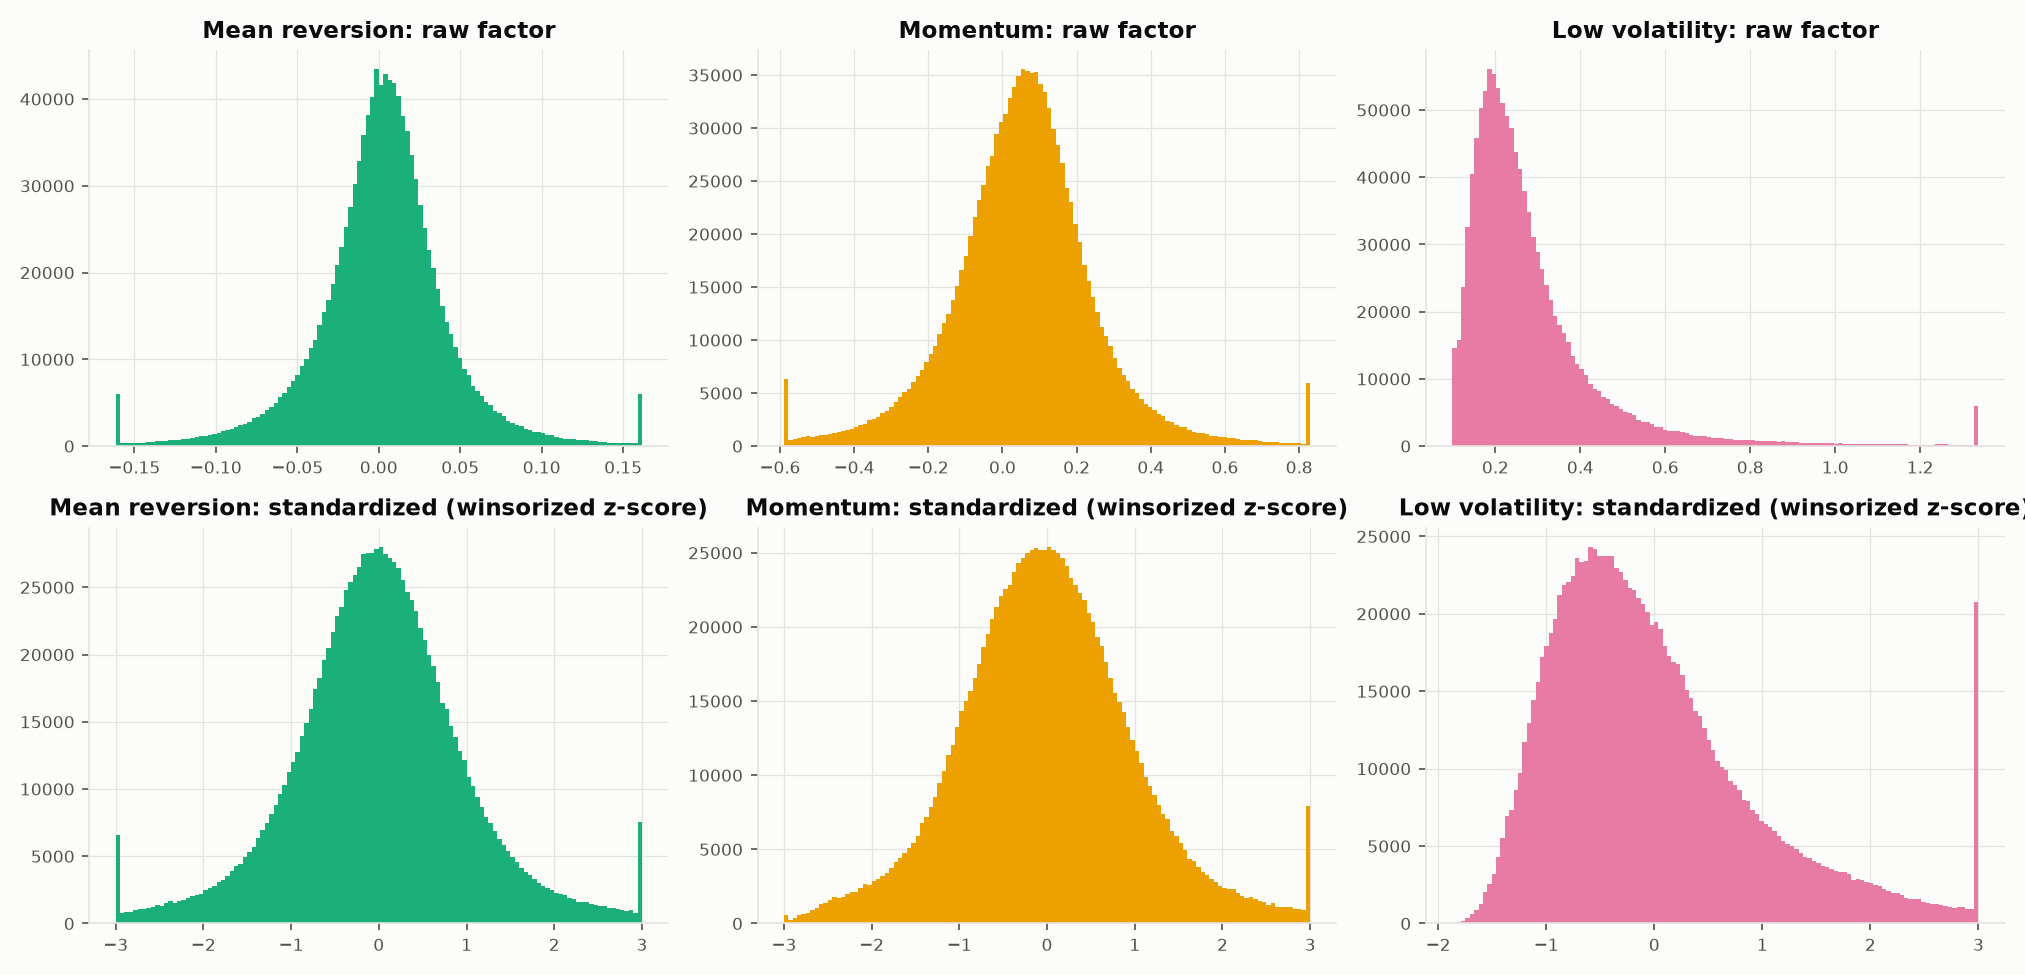

In [5]:
fig("factor_distributions")

## Factor independence (train + validation)

In [6]:
table("factor_correlation_raw_spearman", index_col=0)

,reversal,momentum,volatility
reversal,1.0000,0.0011,-0.0078
momentum,0.0011,1.0000,-0.1282
volatility,-0.0078,-0.1282,1.0000


In [7]:
table("signal_correlation_pearson", index_col=0)

,reversal,momentum,volatility
reversal,1.0000,-0.0008,-0.0043
momentum,-0.0008,1.0000,0.1266
volatility,-0.0043,0.1266,1.0000


In [8]:
table("final_signal_correlation_pearson", index_col=0)

,reversal,momentum,volatility
reversal,1.0000,-0.0036,-0.0079
momentum,-0.0036,1.0000,0.1396
volatility,-0.0079,0.1396,1.0000


In [9]:
table("factor_return_correlation", index_col=0)

,reversal,momentum,volatility
reversal,1.0000,-0.1251,-0.2023
momentum,-0.1251,1.0000,0.4940
volatility,-0.2023,0.4940,1.0000


Cross-sectionally the three signals are close to orthogonal (|corr| <= ~0.14), so combining them
can diversify. Their daily long/short *returns*, however, are more correlated (momentum and low
volatility especially), because in the dollar-neutral version both load on market beta. This is one
reason the beta-neutral variant was evaluated.

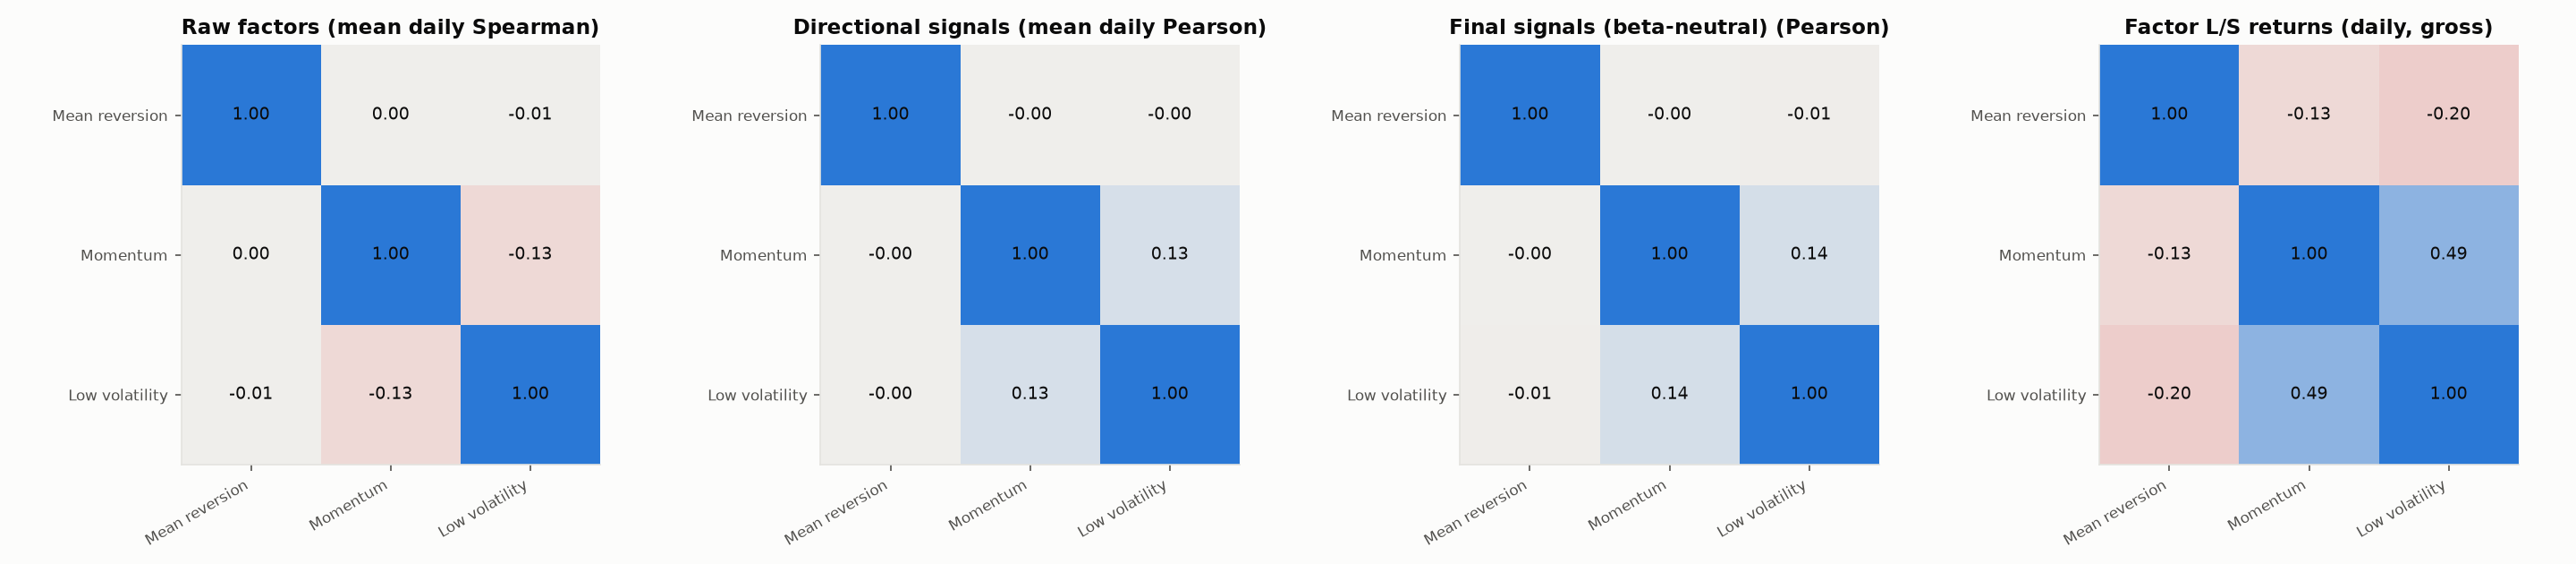

In [10]:
fig("factor_correlation", 1300)